### 42028 : Deep Learning and CNN
### Assignment 2

| Name | Swapnil Ajit Chhatre |
| :--- | :--- |
| Student ID | 25675238 |
| Tutorial | 04 (Wednesday 12.00 - 15.00) |
| Tutor | Mr. Deep Patel |

#### Aim
- To perform Object Detection using FastRCNN

### Contents
1. Section 1 : Loading Datasets
2. Section 2 : Exploratory Data Analysis
3. Section 3 : 
4. Section 4 : 
5. Section 5 : 
6. Section 6 : 

### File Outcome
*An Object Detection model*

### Library imports

In [1]:
!pip install torch torchvision -q

In [19]:
# Import required libraries
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os
import pandas as pd
import sklearn
import tensorflow as tf
import torch
import torchvision
import keras
import xml.etree.ElementTree as ET

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.ops import box_iou
from torchvision.transforms import functional as F
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

TRAIN_DIR = './25675238/Object_Detection/pascal/train'
VALID_DIR = './25675238/Object_Detection/pascal/valid'
TEST_DIR = './25675238/Object_Detection/pascal/test'
CLASSES = ['__background__', 'Ready', 'empty_pod', 'germination', 'pod', 'young']
CLASS_MAP = {
    0: '__background__',
    1: 'Ready',
    2: 'empty_pod',
    3: 'germination',
    4: 'pod',
    5: 'young'
}
COLORS = ['gray', 'lime', 'red', 'cyan', 'yellow', 'magenta']
NUM_CLASSES = len(CLASSES)
torch.cuda.is_available()
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

### Section 1 : Loading dataset

In [3]:
# Checking number of images and annotations
train_images = sum(1 for f in os.listdir(TRAIN_DIR) if f.lower().endswith('.jpg'))
valid_images = sum(1 for f in os.listdir(VALID_DIR) if f.lower().endswith('.jpg'))
test_images = sum(1 for f in os.listdir(TEST_DIR) if f.lower().endswith('.jpg'))

train_labels = sum(1 for f in os.listdir(TRAIN_DIR) if f.lower().endswith('.xml'))
valid_labels = sum(1 for f in os.listdir(VALID_DIR) if f.lower().endswith('.xml'))
test_labels = sum(1 for f in os.listdir(TEST_DIR) if f.lower().endswith('.xml'))

print("Number of training images =", train_images)
print("Number of validation images =", valid_images)
print("Number of testing images =", test_images)

print("Number of training labels =", train_labels)
print("Number of validation labels =", valid_labels)
print("Number of testing labels =", test_labels)

Number of training images = 1057
Number of validation images = 226
Number of testing images = 226
Number of training labels = 1057
Number of validation labels = 226
Number of testing labels = 226


*As we have equal number of training, validation, and testing images and labels. Additional manual annotation is not required*

#### Make custom VOC dataset dictionary using images and annotations

In [24]:
# Function to parce xml files
def parse_voc_xml(xml_file):
    # Parse the XML annotation file using ElementTree
    tree = ET.parse(xml_file)
    root = tree.getroot()

    # Initialize lists to store bounding boxes and labels
    boxes, labels = [], []

    # Loop over all object elements in the XML
    for obj in root.findall("object"):
        # Get the object class name
        label = obj.find("name").text

        # Skip labels that are not in the defined CLASSES list
        if label not in CLASSES:
            continue

        # Convert label name to its corresponding index in CLASSES
        labels.append(CLASSES.index(label))

        # Extract the bounding box coordinates from the XML
        bbox = obj.find("bndbox")
        box = [
            float(bbox.find("xmin").text),  # left
            float(bbox.find("ymin").text),  # top
            float(bbox.find("xmax").text),  # right
            float(bbox.find("ymax").text)   # bottom
        ]
        boxes.append(box)

    # Return list of bounding boxes and their corresponding labels
    return boxes, labels

# Class to create custom VOC dataset
class VOCDataset(Dataset):
    def __init__(self, path, transforms=None):
        self.path = path
        self.transforms = transforms
        self.images = [f for f in os.listdir(path) if f.endswith('.jpg')]
        self.xml = [f for f in os.listdir(path) if f.endswith('.xml')]
        self.images.sort()
        self.xml.sort()

    def __getitem__(self, idx):
        img_path = os.path.join(self.path, self.images[idx])
        xml_path = os.path.join(self.path, self.xml[idx])
        img = Image.open(img_path).convert("RGB")

        boxes, labels = parse_voc_xml(xml_path)
        boxes = torch.as_tensor(boxes, dtype=torch.float32).reshape(-1, 4)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx])
        }
        img = F.to_tensor(img)
        return img, target

    def __len__(self):
        return len(self.images)

#### DataLoader

In [7]:
dataset = VOCDataset(TRAIN_DIR)

data_loader =  DataLoader(
    dataset,
    batch_size = 4,
    shuffle = True,
    collate_fn = lambda x: tuple(zip(*x)),
    num_workers=4,
    pin_memory=True
)

In [8]:
len(dataset.images)

1057

In [9]:
len(dataset.xml)

1057

### Section 2 : Exploring data

In [10]:
# Function to display image and corresponding bounding boxes
def plot_samples(dataset):
    fig, axes = plt.subplots(1, 3, figsize=(18, 25))
    axes = axes.flatten()
    num_samples = 3
    dataset_size = len(dataset)
    random_indices = np.random.choice(dataset_size, num_samples, replace=False)
    for i in range(num_samples):
        img, target = dataset[random_indices[i]]
        ax = axes[i]
        img = img.permute(1, 2, 0).numpy()
        ax.imshow(img)
        boxes = target['boxes'].numpy()
        labels = target['labels'].numpy()
        for box, label in zip(boxes, labels):
            xmin, ymin, xmax, ymax = box
            width, height = xmax - xmin, ymax - ymin
            # Create a Rectangle patch
            rect = patches.Rectangle(
                (xmin, ymin), width, height,
                linewidth=2, edgecolor=COLORS[label], facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(xmin, ymin, CLASS_MAP[label],
                    bbox=dict(facecolor='red', alpha=0.5), color='white')
        ax.set_title(f"Sample {i}", fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.axis('off')
    plt.show()

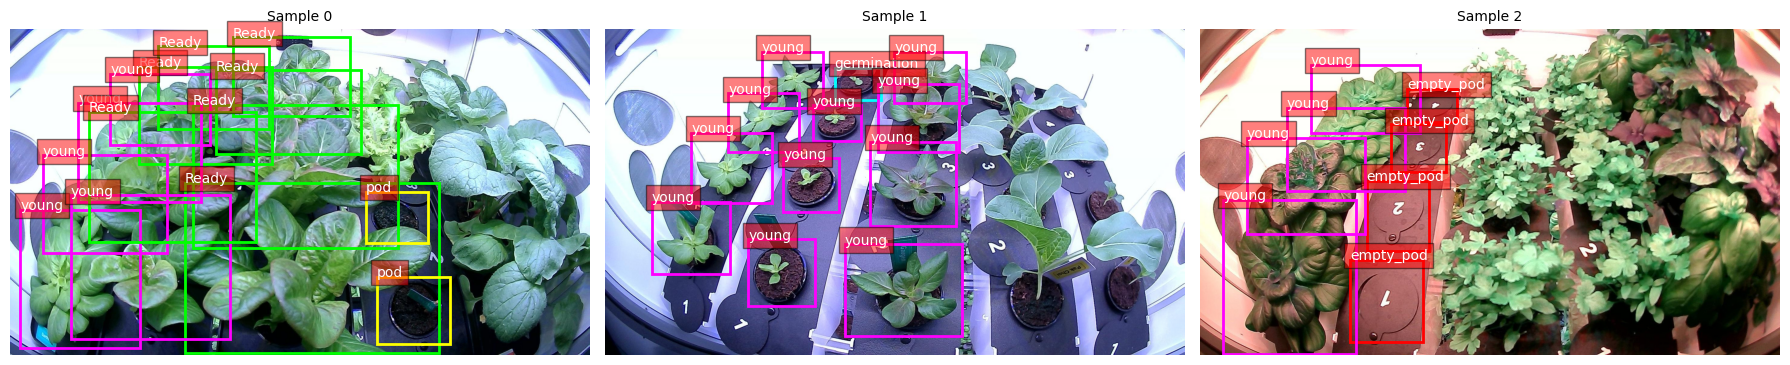

In [11]:
plot_samples(dataset)

### Section 3 : Utilities for Model Training

#### Downloading pre-trained models

In [12]:
def get_model(num_classes, backbone):
    if backbone == "resnet50":
        model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    elif backbone == "mobilenet":
        model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(
            weights="DEFAULT"
        )
    else:
        raise ValueError("Unsupported backbone")

    for param in model.backbone.parameters():
        param.requires_grad = False
    input_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(
        input_features,
        num_classes
    )
    return model

#### Utility for saving Model

In [13]:
def save_model(model, optimizer, epoch, filename="checkpoint.pth"):
    torch.save(
        {
            'epoch':epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict()
        },
        filename
    )
    print(f"✅ Saved model checkpoint to: {filename}")

#### Metric Computation Utility based on COCO dataset

In [23]:
def compute_map_ar(preds, targets, num_classes=len(CLASSES)-1):
    # Initialize the results dictionary with default values
    results = {
        'map': 0, 'map_50': 0, 'map_75': 0,
        'map_per_class': torch.zeros(num_classes),
        'mar_1': 0, 'mar_10': 0, 'mar_100': 0,
        'mar_100_per_class': torch.zeros(num_classes),
    }

    # Lists to hold AP and AR values for each class
    aps = [[] for _ in range(num_classes)]
    ars = [[] for _ in range(num_classes)]

    # Loop through each image's predictions and targets
    for pred, target in zip(preds, targets):
        # Loop through each class (excluding background)
        for class_idx in range(1, num_classes+1):
            # Filter boxes by current class
            gt_mask = target['labels'] == class_idx
            pred_mask = pred['labels'] == class_idx

            gt_boxes = target['boxes'][gt_mask]
            pred_boxes = pred['boxes'][pred_mask]
            # Skip if no GT or predictions
            if len(gt_boxes) == 0 and len(pred_boxes) == 0:
                continue

            # Compute IoUs between predictions and ground truth
            ious = torch.zeros((0, 0))
            if len(gt_boxes) > 0 and len(pred_boxes) > 0:
                ious = box_iou(pred_boxes, gt_boxes)

            # Initialize true positives (TP) and matched GT indices
            tp = torch.zeros(len(pred_boxes))
            matched = set()

            # Match predictions to ground truth based on IoU > 0.5
            for i, row in enumerate(ious):
                max_iou, max_j = torch.max(row, dim=0)
                if max_iou > 0.5 and max_j.item() not in matched:
                    tp[i] = 1
                    matched.add(max_j.item())

            # Compute false positives (FP)
            fp = 1 - tp

            # Cumulative TP and FP for precision-recall curve
            cum_tp = torch.cumsum(tp, dim=0)
            cum_fp = torch.cumsum(fp, dim=0)

            # Compute recall and precision
            recalls = cum_tp / (len(gt_boxes) + 1e-6)
            precisions = cum_tp / (cum_tp + cum_fp + 1e-6)

            # Compute AP (area under precision-recall curve)
            ap = torch.trapz(precisions, recalls) if recalls.numel() > 0 else torch.tensor(0.)
            # AR is the max recall value
            ar = recalls[-1] if recalls.numel() > 0 else torch.tensor(0.)

            # Store per-class AP and AR
            aps[class_idx-1].append(ap.item())
            ars[class_idx-1].append(ar.item())

    # Compute average AP and AR for each class
    ap_avg = torch.tensor([np.mean(cls_ap) if cls_ap else 0. for cls_ap in aps])
    ar_avg = torch.tensor([np.mean(cls_ar) if cls_ar else 0. for cls_ar in ars])

    # Save results
    results['map_per_class'] = ap_avg
    results['mar_100_per_class'] = ar_avg
    results['map'] = ap_avg.mean()
    results['map_50'] = ap_avg.mean()
    results['map_75'] = ap_avg.mean()
    results['mar_100'] = ar_avg.mean()
    results['mar_10'] = ar_avg.mean()
    results['mar_1'] = ar_avg.mean()

    return results

#### Evaluation Utility based on COCO dataset

In [13]:
def evaluate_map(model, dataset, iou_thresholds = [0.5, 0.75]):
    model.eval()
    all_preds, all_targets = [], []
    for img, target in dataset:
        img = img.to(device, non_blocking=True).unsqueeze(0)
        with torch.no_grad():
            pred = model(img)[0]

        keep = pred['scores'] > 0.05
        pred_boxes = pred['boxes'][keep].cpu()
        pred_labels = pred['labels'][keep].cpu()
        pred_scores = pred['scores'][keep].cpu()

        all_preds.append({
            'boxes': pred_boxes,
            'labels': pred_labels,
            'scores': pred_scores
        })

        all_targets.append({
            'boxes': target['boxes'].cpu(),
            'labels': target['labels'].cpu()
        })

        return compute_map_ar(all_preds, all_targets)

#### Training setup

In [15]:
model = get_model(NUM_CLASSES, backbone='resnet50').to(device, non_blocking=True)

In [20]:
# Define the optimizer
optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.0005,
    momentum=0.9,
    weight_decay=0.0005
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# Number of epochs to train
num_epochs = 300
start_epoch = 0

# Logging and checkpointing settings
print_every = 100      # Print loss every N batches
save_every = 20     # Save model every N epochs
val_every = 20        # Validate every N epochs
save_dir = './results_and_models/rcnn_training'

# Initialize logging lists
epoch_losses = []
iteration_losses = []
val_maps = []

val_dataset = VOCDataset(VALID_DIR)


In [21]:
len(val_dataset)

226

### Section 4 :Training Loop

In [25]:
# 1. Initialize a list to store all logs
training_stats = []

for epoch in range(start_epoch, num_epochs):
    model.train()
    # Temporary trackers for the components of Faster R-CNN loss
    epoch_loss_components = {
        "loss_classifier": 0,
        "loss_box_reg": 0,
        "loss_objectness": 0,
        "loss_rpn_box_reg": 0
    }
    total_loss = 0

    for i, (images, targets) in enumerate(data_loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)

        # 2. Track individual loss components
        for k, v in loss_dict.items():
            epoch_loss_components[k] += v.item()

        losses = sum(loss for loss in loss_dict.values())
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    # Step the learning rate scheduler at the end of each epoch
    lr_scheduler.step()

    # Calculate average losses for the epoch
    num_batches = len(data_loader)
    avg_loss = total_loss / num_batches

    # 3. Validation Logic
    val_map, val_map_50, precision, recall, val_mar_100 = 0, 0, 0, 0, 0
    if (epoch + 1) % val_every == 0:
        val_results = evaluate_map(model, val_dataset)
        val_map = val_results.get("map_50_95", 0)
        val_map_50 = val_results.get("map_50", 0)
        precision = val_results.get("mp", 0)
        recall = val_results.get("mr", 0)
        val_mar_100 = val_results.get("mar_100", 0)
        print(f"📈 Validation mAP@.5: {val_map_50:.4f}  mAP@.5:.95: {val_map:.4f}")
    # 4. Create an entry for this epoch
    # NOTE: CSV column names are kept consistent with what plot_faster_rcnn_results expects
    epoch_log = {
        "epoch":                  epoch + 1,
        "train/total_loss":       avg_loss,
        "train/loss_classifier":  epoch_loss_components["loss_classifier"] / num_batches,
        "train/loss_box_reg":     epoch_loss_components["loss_box_reg"] / num_batches,
        "train/loss_obj":         epoch_loss_components["loss_objectness"] / num_batches,
        "train/loss_rpn":         epoch_loss_components["loss_rpn_box_reg"] / num_batches,
        "metrics/precision":      precision,
        "metrics/recall":         recall,
        "metrics/mAP_0.5":        val_map_50,
        "metrics/mAP_0.5_0.95":   val_map,
        "metrics/mAR_100":        val_mar_100,
    }
    training_stats.append(epoch_log)

    # 5. Save/Update the CSV every epoch (prevents data loss if crash occurs)
    df = pd.DataFrame(training_stats)
    df.to_csv(os.path.join(save_dir, "results.csv"), index=False)

    if (epoch + 1) % save_every == 0:
        save_model(
            model,
            optimizer,
            epoch + 1,
            filename=str(os.path.join(save_dir, f"checkpoint_epoch_{epoch + 1}.pth")
            )
        )


AssertionError: Expected target boxes to be a tensor of shape [N, 4], got torch.Size([0]).

In [17]:
for epoch in range(start_epoch, num_epochs):
    model.train()  # Set model to training mode
    total_loss = 0  # Track total loss for the epoch

    for i, (images, targets) in enumerate(data_loader):
        # Move all images and targets to the selected device
        images = [img.to(device, non_blocking=True) for img in images]
        targets = [{k: v.to(device, non_blocking=True) for k, v in t.items()} for t in targets]

        # Get the loss dict from the model
        loss_dict = model(images, targets)

        # Combine all losses into a single scalar
        losses = sum(loss for loss in loss_dict.values())

        # Backward pass and optimizer step
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        # Accumulate batch loss and append to losses per iteration
        total_loss += losses.item()
        iteration_losses.append(losses.item())
        # Print batch loss every few iterations
        if (i + 1) % print_every == 0:
            print(f"  [Epoch {epoch+1}, Iter {i+1}] Loss: {losses.item():.4f}")

    # Print total loss at the end of the epoch and store losses for loss curve
    print(f"Epoch [{epoch+1}/{num_epochs}], Total Loss: {total_loss:.4f}")
    epoch_losses.append(total_loss)

    if (epoch+1) % val_every == 0:
        # Evaluate on validation set
        val_results = evaluate_map(model, val_dataset)
        val_map = val_results["map"].item()
        val_maps.append(val_map)
        print(f"Validation mAP at epoch {epoch+1}: {val_map:.4f}")

    # Save checkpoint for loss every few epochs
    if (epoch + 1) % save_every == 0:
        save_model(
          model,
          optimizer,
          epoch+1,
          filename=str(
              os.path.join(
                  save_dir,
                  f"checkpoint_fasterRcnn_epoch_{epoch+1}.pth"
              )
          )
      )

# save final model after training is complete
save_model(model, optimizer, epoch+1, filename=str(os.path.join(save_dir, f"Final_model_fasterRcnn_epoch_{epoch+1}.pth")))


  [Epoch 1, Iter 250] Loss: 0.8064


Epoch [1/300], Total Loss: 325.3357


  [Epoch 2, Iter 250] Loss: 0.6618


Epoch [2/300], Total Loss: 248.5836


  [Epoch 3, Iter 250] Loss: 0.6060


...

  [Epoch 5, Iter 250] Loss: 0.5653


Epoch [5/300], Total Loss: 208.9926


  [Epoch 6, Iter 250] Loss: 0.5784


Epoch [6/300], Total Loss: 202.9919


KeyboardInterrupt: 

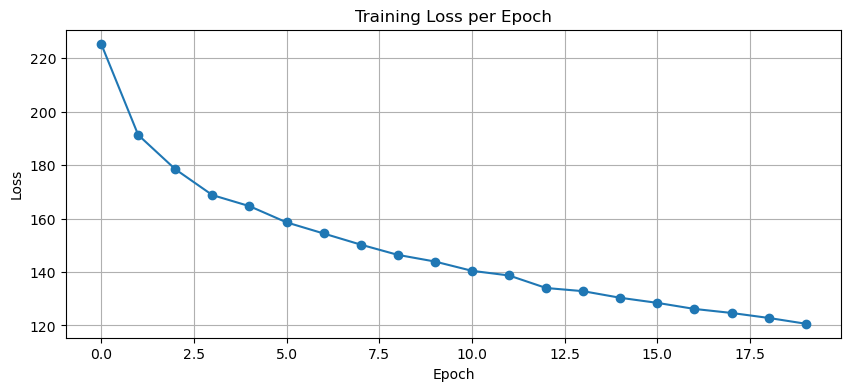

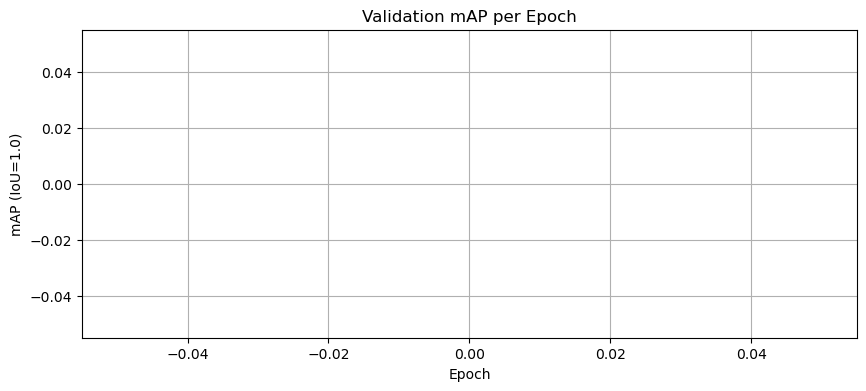

In [46]:
# Plot training loss per epoch
plt.figure(figsize=(10, 4))
plt.plot(epoch_losses, marker='o')
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Plot validation mAP per epoch
plt.figure(figsize=(10, 4))
plt.plot(val_maps, marker='s', color='green')
plt.title("Validation mAP per Epoch")
plt.xlabel("Epoch")
plt.ylabel("mAP (IoU=1.0)")
plt.grid(True)
plt.show()

In [47]:
train_results = evaluate_map(model, dataset)

# Print overall mAP/mAR results for the training set
print("📊 Train set mAP/mAR results:")
for k, v in train_results.items():
    # Convert torch tensors to NumPy arrays for clean printing
    if isinstance(v, torch.Tensor):
        print(f"{k}: {v.numpy()}")
    else:
        print(f"{k}: {v}")

📊 Train set mAP/mAR results:
map: 0.33816760778427124
map_50: 0.33816760778427124
map_75: 0.33816760778427124
map_per_class: [0.         0.81469798 0.         0.         0.87614006]
mar_1: 0.3999999642372131
mar_10: 0.3999999642372131
mar_100: 0.3999999642372131
mar_100_per_class: [0.         0.99999988 0.         0.         0.99999994]


In [48]:
test_dataset = VOCDataset(TEST_DIR)

# Create a DataLoader for the test set
test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,  # No shuffling needed for evaluation
    collate_fn=lambda x: tuple(zip(*x))  # Handle varying-size targets
)

In [49]:
# Evaluate the model on the test dataset
test_results = evaluate_map(model, test_dataset)

# Print overall mAP/mAR results for the test set
print("\n📊 Test set mAP/mAR results:")
for k, v in test_results.items():
    # Convert torch tensors to NumPy arrays for cleaner display
    if isinstance(v, torch.Tensor):
        print(f"{k}: {v.numpy()}")
    else:
        print(f"{k}: {v}")


📊 Test set mAP/mAR results:
map: 0.35833321809768676
map_50: 0.35833321809768676
map_75: 0.35833321809768676
map_per_class: [0.         0.8749997  0.         0.         0.91666639]
mar_1: 0.3999999642372131
mar_10: 0.3999999642372131
mar_100: 0.3999999642372131
mar_100_per_class: [0.         0.99999988 0.         0.         0.99999994]
